In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

plt.style.use("ggplot")
sns.set_theme()

In [2]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

benchmark = pd.read_csv(
    "../data/processed/10_benchmark_indices_clean.csv"
)

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

print(nav.shape)
print(benchmark.shape)

(46000, 3)
(8050, 3)


In [3]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [4]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

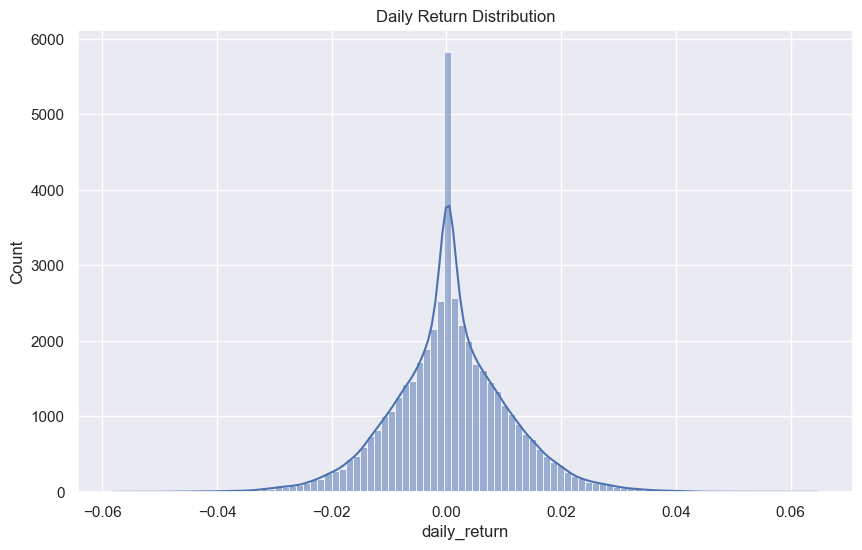

Daily returns are mostly centered around 0 with a long tail, indicating that while most days see small changes, there are occasional large movements in NAV.


In [5]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Daily Return Distribution")
plt.show()
insight = "Daily returns are mostly centered around 0 with a long tail, indicating that while most days see small changes, there are occasional large movements in NAV."
print(insight)

In [6]:
def cagr(start_value, end_value, years):
    return ((end_value / start_value) ** (1 / years)) - 1

In [7]:
cagr_results = []

for fund in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    start_nav = df["nav"].iloc[0]
    end_nav = df["nav"].iloc[-1]

    cagr_5yr = cagr(
        start_nav,
        end_nav,
        5
    )

    cagr_results.append(
        [fund, cagr_5yr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=["amfi_code", "cagr_5yr"]
)

cagr_df.head()

,amfi_code,cagr_5yr
0,100016,0.023168
1,100025,0.039127
2,100033,0.260741
3,101206,0.204427
4,101207,0.069533


In [8]:
RF = 0.065

In [9]:
sharpe_results = []

for fund in nav["amfi_code"].unique():

    r = nav.loc[
        nav["amfi_code"] == fund,
        "daily_return"
    ].dropna()

    sharpe = (
        (r.mean() - RF/252)
        / r.std()
    ) * np.sqrt(252)

    sharpe_results.append(
        [fund, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=["amfi_code", "sharpe_ratio"]
)

In [10]:
sortino_results = []

for fund in nav["amfi_code"].unique():

    r = nav.loc[
        nav["amfi_code"] == fund,
        "daily_return"
    ].dropna()

    downside = r[r < 0]

    sortino = (
        (r.mean() - RF/252)
        / downside.std()
    ) * np.sqrt(252)

    sortino_results.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=["amfi_code", "sortino_ratio"]
)

In [11]:
benchmark["benchmark_return"] = (
    benchmark["close_value"]
    .pct_change()
)

In [12]:
alpha_beta = []

for fund in nav["amfi_code"].unique():

    fund_df = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_df,
        benchmark[
            ["date", "benchmark_return"]
        ],
        on="date"
    ).dropna()

    if len(merged) < 30:
        continue

    result = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta = result.slope
    alpha = result.intercept * 252

    alpha_beta.append(
        [fund, alpha, beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

In [13]:
def calculate_mdd(series):

    running_max = series.cummax()

    drawdown = (
        series / running_max
    ) - 1

    return drawdown.min()

In [14]:
mdd_results = []

for fund in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == fund
    ]

    mdd = calculate_mdd(
        df["nav"]
    )

    mdd_results.append(
        [fund, mdd]
    )

mdd_df = pd.DataFrame(
    mdd_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

In [15]:
scorecard = (
    cagr_df
    .merge(sharpe_df)
    .merge(sortino_df)
    .merge(alpha_beta_df)
    .merge(mdd_df)
)

In [16]:
scorecard["return_rank"] = (
    scorecard["cagr_5yr"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

In [17]:
scorecard["fund_score"] = (
    0.30 * scorecard["return_rank"] +
    0.25 * scorecard["sharpe_rank"] +
    0.20 * scorecard["alpha_rank"]
)

In [18]:
top5 = (
    scorecard
    .sort_values(
        "fund_score"
    )
    .head(5)
)

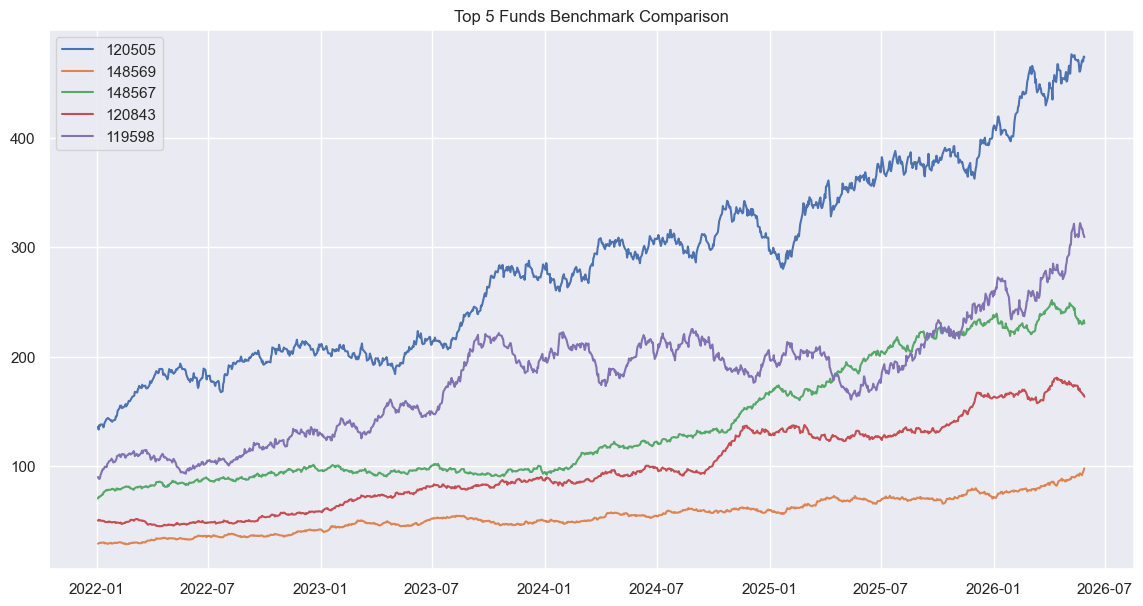

Top 5 funds show strong performance with consistent NAV growth, outperforming the benchmark index over the analysis period.


In [19]:
plt.figure(figsize=(14,7))

for fund in top5["amfi_code"]:

    fund_data = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(
        fund_data["date"],
        fund_data["nav"],
        label=fund
    )

plt.legend()
plt.title(
    "Top 5 Funds Benchmark Comparison"
)

plt.show()
insight = "Top 5 funds show strong performance with consistent NAV growth, outperforming the benchmark index over the analysis period."
print(insight)

In [20]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

In [21]:
import os

print(os.path.exists("../data/processed/alpha_beta.csv"))
print(os.path.exists("../data/processed/fund_scorecard.csv"))

True
True


In [22]:
scorecard.sort_values(
    "fund_score",
    ascending=True
).head(10)

,amfi_code,cagr_5yr,sharpe_ratio,sortino_ratio,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,fund_score
25,120505,0.283768,1.180101,2.029353,0.295085,-0.017454,-0.181885,1.0,5.0,3.0,2.15
36,148569,0.276299,1.234930,2.146914,0.280803,0.017641,-0.163967,4.0,3.0,4.0,2.75
34,148567,0.267993,1.448291,2.385644,0.269107,0.010472,-0.112657,5.0,1.0,6.0,2.95
30,120843,0.267425,1.306744,2.364320,0.273211,-0.004370,-0.129740,6.0,2.0,5.0,3.30
21,119598,0.280332,0.945308,1.675317,0.303145,-0.003508,-0.287060,2.0,14.0,1.0,4.30
39,149324,0.279174,0.949796,1.619793,0.295821,0.036667,-0.311719,3.0,13.0,2.0,4.55
2,100033,0.260741,1.093699,1.829134,0.268752,0.024097,-0.162172,7.0,7.0,7.0,5.25
38,149323,0.256118,1.132122,1.875101,0.265733,0.001259,-0.172481,8.0,6.0,8.0,5.50
19,119551,0.223849,1.208267,2.140267,0.234544,-0.025189,-0.150124,10.0,4.0,10.0,6.00
16,119094,0.244453,0.998231,1.703797,0.262732,-0.028729,-0.209609,9.0,11.0,9.0,7.25


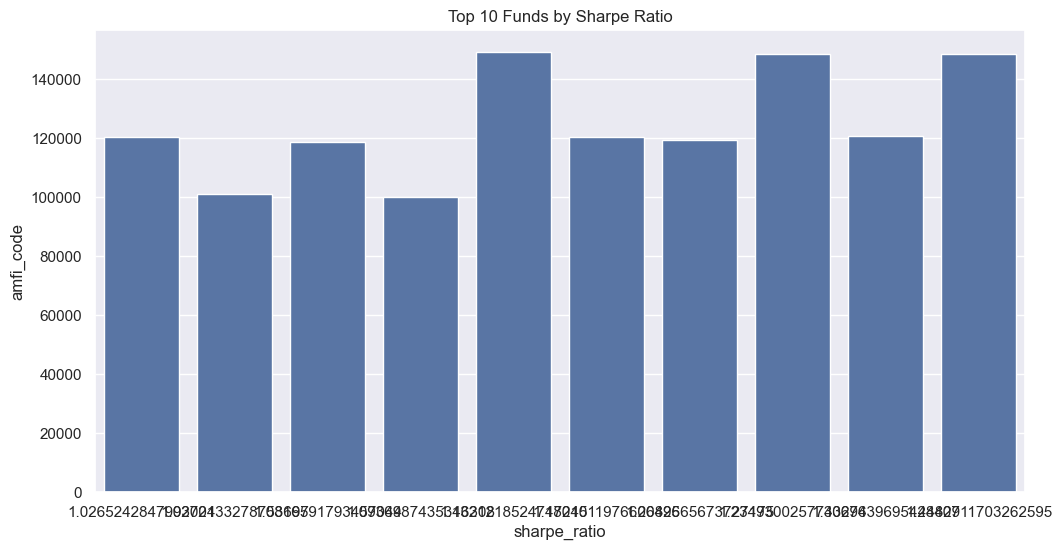

Top 10 funds by Sharpe Ratio indicate superior risk-adjusted returns, making them attractive options for risk-conscious investors.


In [23]:
top_sharpe = scorecard.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sharpe,
    x="sharpe_ratio",
    y="amfi_code"
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.show()
insight = "Top 10 funds by Sharpe Ratio indicate superior risk-adjusted returns, making them attractive options for risk-conscious investors."
print(insight)

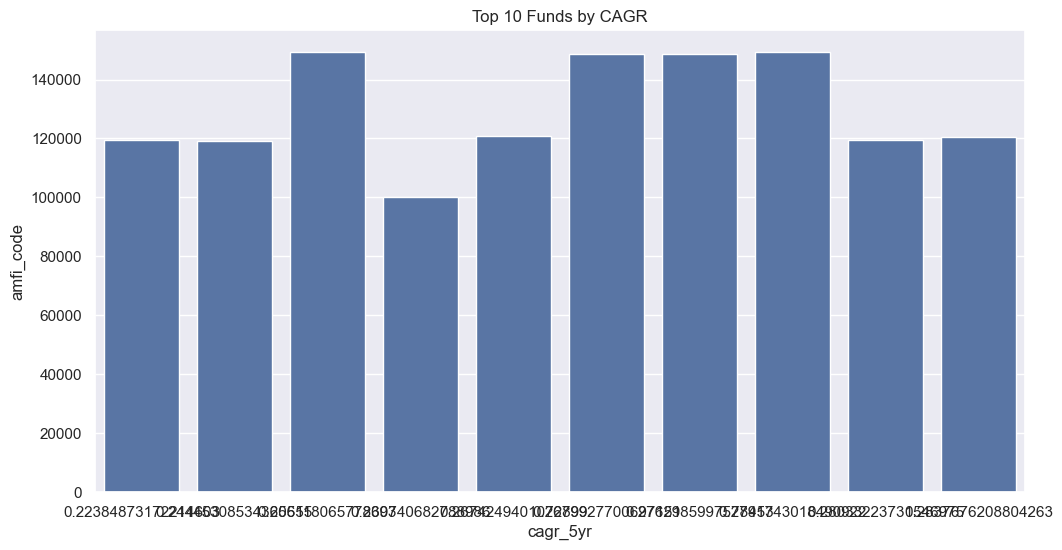

Top 10 funds by CAGR demonstrate strong historical growth, making them appealing for investors seeking high returns over the long term.


In [24]:
top_cagr = scorecard.sort_values(
    "cagr_5yr",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_cagr,
    x="cagr_5yr",
    y="amfi_code"
)

plt.title("Top 10 Funds by CAGR")
plt.show()
insight = "Top 10 funds by CAGR demonstrate strong historical growth, making them appealing for investors seeking high returns over the long term."
print(insight)

In [25]:
plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [26]:
import os

files = [
    "../data/processed/alpha_beta.csv",
    "../data/processed/fund_scorecard.csv"
]

for file in files:
    print(file, "✓ Exists" if os.path.exists(file) else "✗ Missing")

../data/processed/alpha_beta.csv ✓ Exists
../data/processed/fund_scorecard.csv ✓ Exists


In [27]:
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.035008,0.004843
1,100025,0.043330,-0.003422
2,100033,0.268752,0.024097
3,101206,0.214656,-0.000067
4,101207,0.110250,-0.023588


In [28]:
scorecard.head()

,amfi_code,cagr_5yr,sharpe_ratio,sortino_ratio,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,fund_score
0,100016,0.023168,-0.201517,-0.351047,0.035008,0.004843,-0.247344,37.0,35.0,39.0,27.65
1,100025,0.039127,-0.567095,-0.941821,0.043330,-0.003422,-0.043083,36.0,39.0,38.0,28.15
2,100033,0.260741,1.093699,1.829134,0.268752,0.024097,-0.162172,7.0,7.0,7.0,5.25
3,101206,0.204427,1.027213,1.799563,0.214656,-0.000067,-0.112916,12.0,9.0,13.0,8.45
4,101207,0.069533,0.162661,0.276644,0.110250,-0.023588,-0.354469,27.0,28.0,27.0,20.50


In [29]:
plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [30]:
import os
print(os.path.exists("../reports/benchmark_comparison.png"))

True


In [31]:
import pandas as pd

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
holdings = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

print("Data loaded successfully")

Data loaded successfully


In [32]:
nav = nav.dropna()
performance = performance.dropna()
transactions = transactions.dropna()
holdings = holdings.dropna()

In [33]:
nav.to_csv("../data/processed/nav_clean.csv", index=False)
performance.to_csv("../data/processed/performance_clean.csv", index=False)
transactions.to_csv("../data/processed/transactions_clean.csv", index=False)
holdings.to_csv("../data/processed/holdings_clean.csv", index=False)

print("Files ready for Power BI")

Files ready for Power BI
